In [237]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# ======== REUSABLE PLOTTING FUNCTION ========
def plot_comparison(data, title, ylabel, kind='bar', color_list=None):
    """Reusable function for consistent plotting across notebook."""
    fig, ax = plt.subplots(figsize=(8, 4))
    if kind == 'bar':
        ax.bar(data.index, data.values, color=color_list or 'steelblue', edgecolor='white')
    elif kind == 'barh':
        ax.barh(data.index, data.values, color=color_list or 'steelblue', edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=15)
    plt.tight_layout()
    return fig, ax

In [238]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (2640, 12)
Columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## Section 1 — Data Cleaning
Checking for duplicates and missing values before modeling.

In [239]:
print("Missing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)
df.describe()

Missing values:
 Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Data types:
 Year                      int64
Month                     int64
Region                      str
Model                       str
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type                 str
Charging_Stations         int64
dtype: object


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [240]:
print("Before cleaning:", df.shape)
df.drop_duplicates(inplace=True)
print("After removing duplicates:", df.shape)
print("Missing values:", df.isnull().sum().sum(), "— None!")

Before cleaning: (2640, 12)
After removing duplicates: (2640, 12)
Missing values: 0 — None!


## Section 2 — Exploratory Data Analysis (EDA)
Visualizing delivery trends by region, model, year and checking feature correlations.

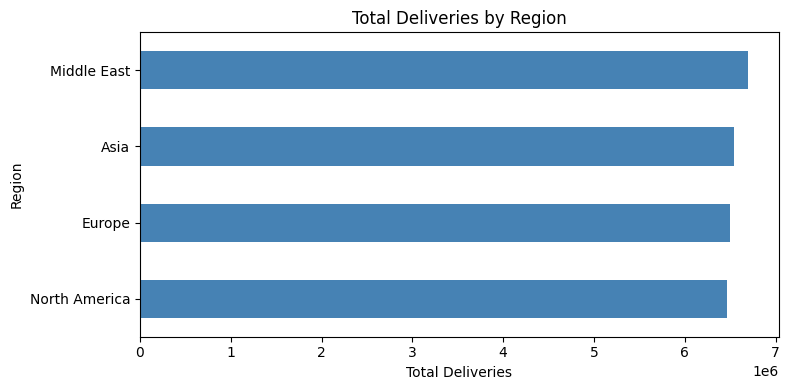

In [241]:
# Deliveries by Region
region_del = df.groupby('Region')['Estimated_Deliveries'].sum().sort_values()
region_del.plot(kind='barh', color='steelblue', figsize=(8, 4))
plt.title('Total Deliveries by Region')
plt.xlabel('Total Deliveries')
plt.tight_layout()
plt.show()

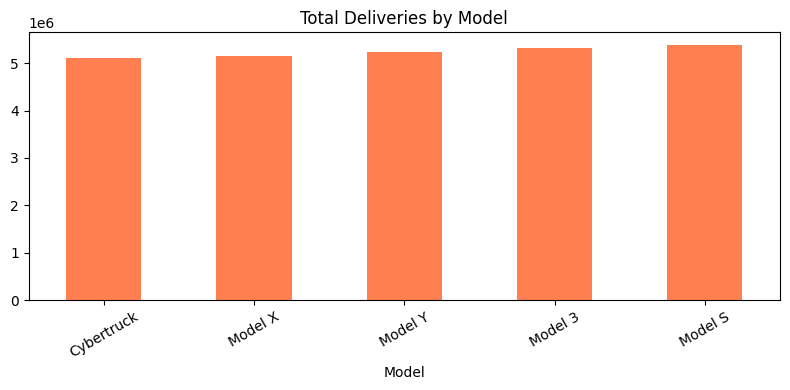

In [242]:
# Deliveries by Model
model_del = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values()
model_del.plot(kind='bar', color='coral', figsize=(8, 4))
plt.title('Total Deliveries by Model')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

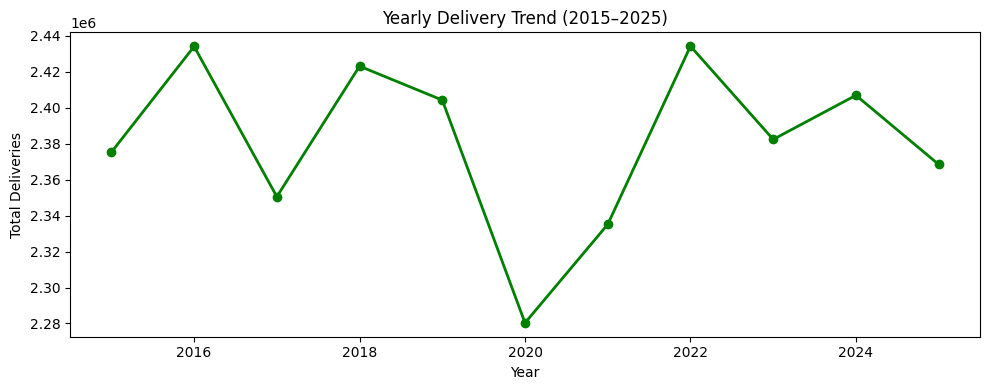

In [243]:
# Yearly delivery trend
yearly = df.groupby('Year')['Estimated_Deliveries'].sum()
plt.figure(figsize=(10, 4))
plt.plot(yearly.index, yearly.values, marker='o', color='green', linewidth=2)
plt.title('Yearly Delivery Trend (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Total Deliveries')
plt.tight_layout()
plt.show()

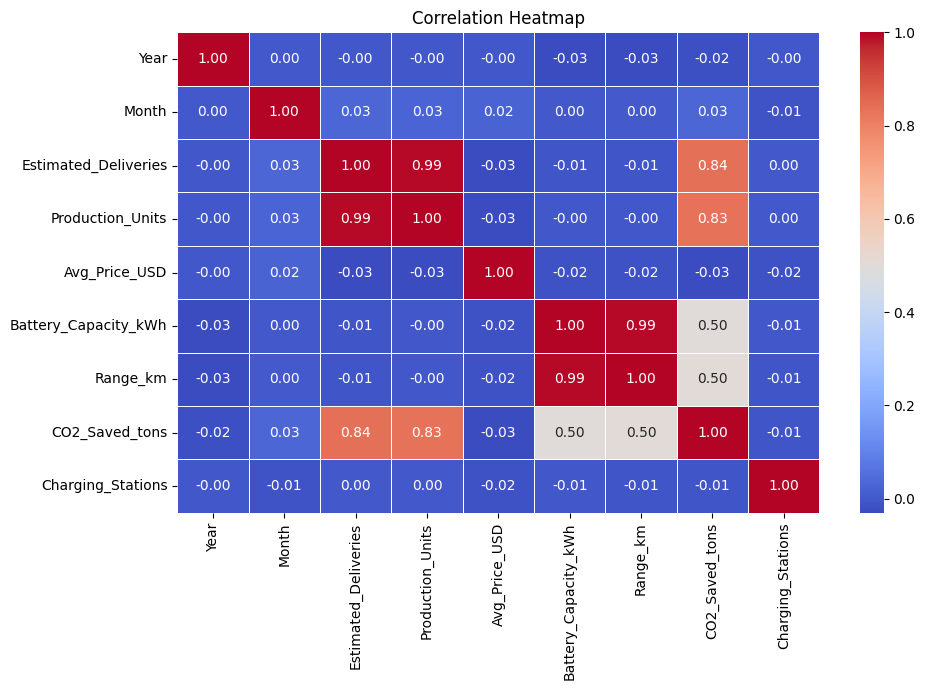

EDA complete


In [257]:
# Correlation heatmap
num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()
print("EDA complete")

## Section 3 — Encoding + Feature Engineering
Converting categorical columns to numeric and creating new meaningful features.
- production_efficiency

- price_category

- co2_per_production

- Lag_1

In [258]:

df_ml = df.copy()
df_ml = df_ml.sort_values(['Year', 'Month']).reset_index(drop=True)

# ======== STORE SEPARATE ENCODERS FOR REUSABILITY ========
encoder_dict = {}
for col in ['Region', 'Model', 'Source_Type']:
    le = LabelEncoder()
    df_ml[f'{col}_enc'] = le.fit_transform(df_ml[col])
    encoder_dict[col] = le  # Store for potential inverse transforms
    print(f"Encoded: {col} → {col}_enc (kept original)")

df_ml['production_efficiency'] = df_ml['Production_Units'] / (df_ml['Charging_Stations'] + 1)
df_ml['price_category'] = pd.cut(df_ml['Avg_Price_USD'], bins=5, labels=False)
df_ml['co2_per_production'] = df_ml['CO2_Saved_tons'] / (df_ml['Production_Units'] + 1)

print("\nNew features added")
df_ml['Lag_1'] = df_ml.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(1)
df_ml['Lag_1'] = df_ml['Lag_1'].fillna(0)
df_ml.head()

Encoded: Region → Region_enc (kept original)
Encoded: Model → Model_enc (kept original)
Encoded: Source_Type → Source_Type_enc (kept original)

New features added


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Region_enc,Model_enc,Source_Type_enc,production_efficiency,price_category,co2_per_production,Lag_1
0,2015,1,Middle East,Model Y,10348,10835,85599.95,82,488,757.47,Estimated (Region),5991,2,4,0,1.808244,2,0.069903,0.0
1,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,0,4,2,3.162150,0,0.045712,0.0
2,2015,1,Europe,Model Y,10835,11723,62939.81,120,718,1166.93,Official (Quarter),12301,1,4,2,0.952934,0,0.099533,0.0
3,2015,1,North America,Model X,8122,8343,62838.32,75,423,515.34,Official (Quarter),9297,3,3,2,0.897290,0,0.061762,0.0
4,2015,1,Middle East,Model S,13902,15423,94629.02,75,445,927.96,Official (Quarter),8666,2,2,2,1.779508,3,0.060163,0.0


## Section 4 — Train/Test Split + Feature Scaling
80/20 split with StandardScaler to normalize features before regression.
Scaler is fit only on training data to prevent data leakage into the test set.

In [246]:

# ======== EXPLICIT FEATURE SELECTION ========
FEATURES = ['Year', 'Month', 'Region_enc', 'Model_enc', 'Source_Type_enc',
            'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
            'CO2_Saved_tons', 'Charging_Stations',
            'production_efficiency', 'price_category', 'co2_per_production', 'Lag_1']

X = df_ml[FEATURES]
y = df_ml['Estimated_Deliveries']

# ======== CONSISTENT CHRONOLOGICAL SPLIT (80/20) ========
split_idx = int(len(df_ml) * 0.8)
X_train = X[:split_idx]
X_test  = X[split_idx:]
y_train = y[:split_idx]
y_test  = y[split_idx:]


# ======== FIT SCALER ON TRAIN, TRANSFORM TEST (NO LEAKAGE) ========
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Features: {len(FEATURES)}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Features: 15
Train: (2112, 15) | Test: (528, 15)


## Section 5 — Model Training
Training 3 regression models to predict Estimated_Deliveries.
- **Linear Regression**: baseline with no regularization
- **Ridge Regression L2**: penalizes large coefficients, handles multicollinearity
- **Lasso Regression L1**: can zero out coefficients, acts as feature selection

In [259]:
# ======== MODEL TRAINING ========
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression' : Ridge(alpha=1.0),
    'Lasso Regression' : Lasso(alpha=0.1)
}

results        = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mae    = mean_absolute_error(y_test, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    r2     = r2_score(y_test, y_pred)
    results[name]        = {'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'R2': round(r2, 4)}
    trained_models[name] = model
    
    print(f"{name}\n  MAE: {mae:.2f}  RMSE: {rmse:.2f}  R²: {r2:.4f}\n")

print("Model Training complete")

Linear Regression
  MAE: 128.02  RMSE: 181.50  R²: 0.9976

Ridge Regression
  MAE: 129.83  RMSE: 183.11  R²: 0.9975

Lasso Regression
  MAE: 128.13  RMSE: 181.55  R²: 0.9976

Model Training complete


## Section 6 — Bias Variance Tradeoff
Using 5-fold cross validation to check model stability.
High std means high variance (overfitting). Low mean R² means high bias (underfitting).

In [248]:
from sklearn.model_selection import TimeSeriesSplit

# Initialize the time series cross-validator
tscv = TimeSeriesSplit(n_splits=5)

# Create an empty list to gather the evaluation stats
cv_records = []

for name, model in trained_models.items():
    # Execute the chronological cross validation
    cv = cross_val_score(model, X_train_scaled, y_train, cv=tscv, scoring='r2')
    
    # Store metrics cleanly into a dictionary instead of printing
    cv_records.append({
        'Model Name': name,
        'Fold Scores ($R^2$)': cv.round(3).tolist(),
        'Mean $R^2$': round(cv.mean(), 4),
        'Std Dev': round(cv.std(), 4),
        'Stability Status': 'High variance' if cv.std() > 0.1 else 'Stable'
    })

# Convert to DataFrame to generate a rich HTML presentation table
cv_summary_df = pd.DataFrame(cv_records)
cv_summary_df

,Model Name,Fold Scores ($R^2$),Mean $R^2$,Std Dev,Stability Status
0,Linear Regression,"[0.998, 0.998, 0.998, 0.998, 0.998]",0.9980,0.0002,Stable
1,Ridge Regression,"[0.997, 0.998, 0.998, 0.998, 0.998]",0.9978,0.0004,Stable
2,Lasso Regression,"[0.998, 0.998, 0.998, 0.998, 0.998]",0.9980,0.0002,Stable


## Section 7 — Hyperparameter Tuning
Using GridSearchCV to find the best alpha for Ridge Regression.
GridSearchCV tests every combination in the grid using cross validation, so the test set is never touched during tuning.

In [260]:
# ======== HYPERPARAMETER GRID WITH LOGSPACE (EXPONENTIAL SPACING) ========
param_grid = {'alpha': np.logspace(-3, 2, 6)}

grid = GridSearchCV(Ridge(), param_grid, cv=tscv, scoring='r2')
grid.fit(X_train_scaled, y_train)

tuned_test_r2 = r2_score(y_test, grid.best_estimator_.predict(X_test_scaled))

tuning_summary_df = pd.DataFrame([{
    'Optimal Alpha (alpha)': grid.best_params_['alpha'],
    'Best Validation R2 Score': round(grid.best_score_, 4),
    'Final Tuned Test R2 Score': round(tuned_test_r2, 4),
    'Tuning Optimization Status': 'Success'
}])

tuning_summary_df

,Optimal Alpha (alpha),Best Validation R2 Score,Final Tuned Test R2 Score,Tuning Optimization Status
0,0.001,0.998,0.9976,Success


## Section 8 — Time Series Analysis
Tesla delivery data has a strong time component. Analyzing monthly trends, rolling statistics and testing for stationarity using the ADF test.

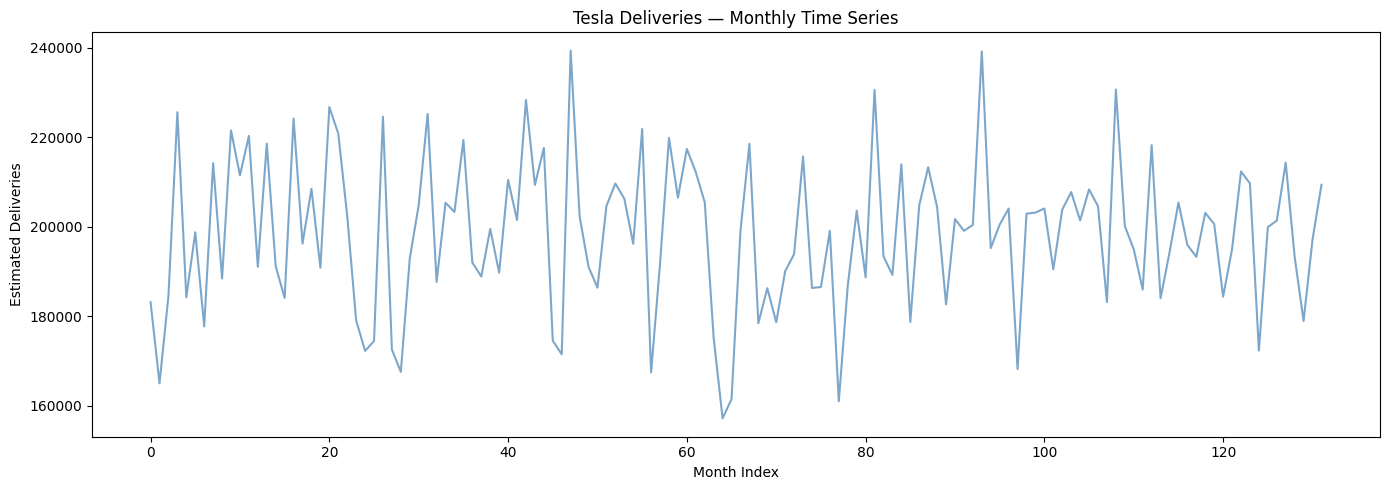

In [250]:
monthly = df.groupby(['Year', 'Month'])['Estimated_Deliveries'].sum().reset_index()
ts      = monthly['Estimated_Deliveries']

plt.figure(figsize=(14, 5))
plt.plot(ts.values, label='Monthly Deliveries', color='steelblue', alpha=0.7)
plt.title('Tesla Deliveries — Monthly Time Series')
plt.xlabel('Month Index')
plt.ylabel('Estimated Deliveries')
plt.tight_layout()
plt.show()

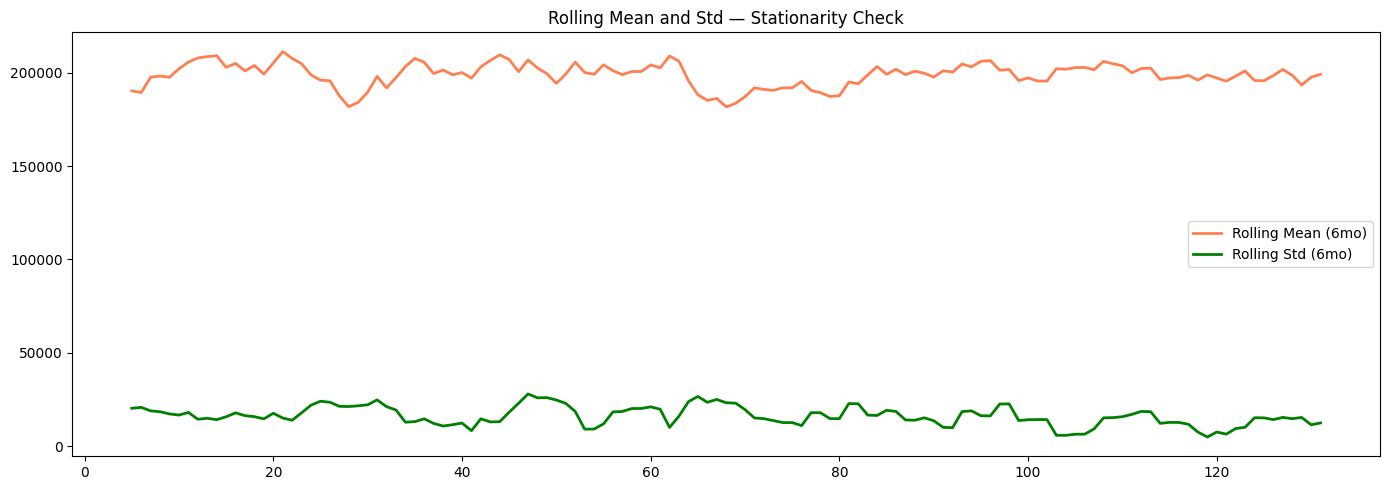

ADF p-value : 0.0000
Stationary? : True


In [251]:

rolling_6 = ts.rolling(6)
mean_6 = rolling_6.mean()
std_6 = rolling_6.std()

plt.figure(figsize=(14, 5))
plt.plot(mean_6.values, label='Rolling Mean (6mo)', color='coral',  lw=2)
plt.plot(std_6.values,  label='Rolling Std (6mo)',  color='green',  lw=2)
plt.title('Rolling Mean and Std — Stationarity Check')
plt.legend()
plt.tight_layout()
plt.show()

adf = adfuller(ts.dropna())
print(f"ADF p-value : {adf[1]:.4f}")
print(f"Stationary? : {adf[1] < 0.05}")

## Section 8b — Forecasting + Chronological Split
For time series data, always use chronological split — not random split.
Random split mixes future data into training which is a form of data leakage.

In [252]:
ts_full   = monthly['Estimated_Deliveries'].reset_index(drop=True)
split_idx = int(len(ts_full) * 0.8)
train_ts  = ts_full[:split_idx]
test_ts   = ts_full[split_idx:]

forecast_value = train_ts.rolling(6).mean().iloc[-1]

print(f"Train months : {len(train_ts)}")
print(f"Test months  : {len(test_ts)}")
print(f"Baseline Forecast (next month) : {forecast_value:,.0f} deliveries")
print(f"Actual first test value        : {test_ts.iloc[0]:,.0f} deliveries")

Train months : 105
Test months  : 27
Baseline Forecast (next month) : 201,817 deliveries
Actual first test value        : 208,379 deliveries


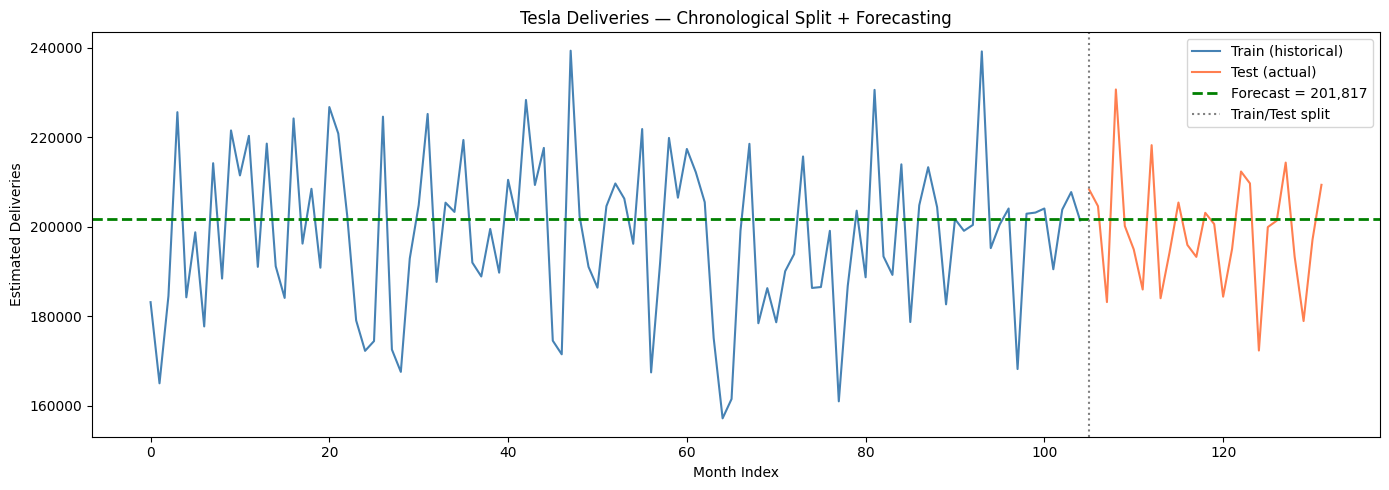

In [253]:
plt.figure(figsize=(14, 5))
plt.plot(train_ts.index, train_ts.values, label='Train (historical)', color='steelblue')
plt.plot(test_ts.index,  test_ts.values,  label='Test (actual)',      color='coral')
plt.axhline(y=forecast_value, color='green', linestyle='--', linewidth=2,
            label=f'Forecast = {forecast_value:,.0f}')
plt.axvline(x=split_idx, color='gray', linestyle=':', linewidth=1.5, label='Train/Test split')
plt.title('Tesla Deliveries — Chronological Split + Forecasting')
plt.xlabel('Month Index')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

## Section 9 — Final Model Comparison
Comparing all 3 models on R² and MAE to select the best performer.

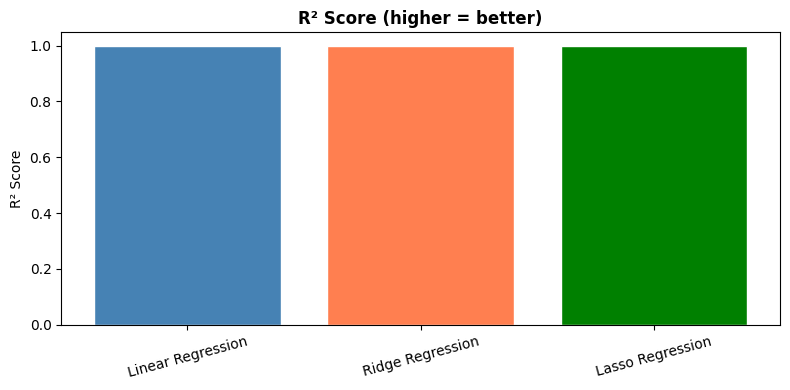

In [254]:
# ======== USE CONSOLIDATED PLOTTING FUNCTION ========
model_names = list(results.keys())
r2_series = pd.Series([results[m]['R2'] for m in model_names], index=model_names)
plot_comparison(r2_series, 'R² Score (higher = better)', 'R² Score', kind='bar',
                color_list=['steelblue', 'coral', 'green'][:len(model_names)])
plt.show()

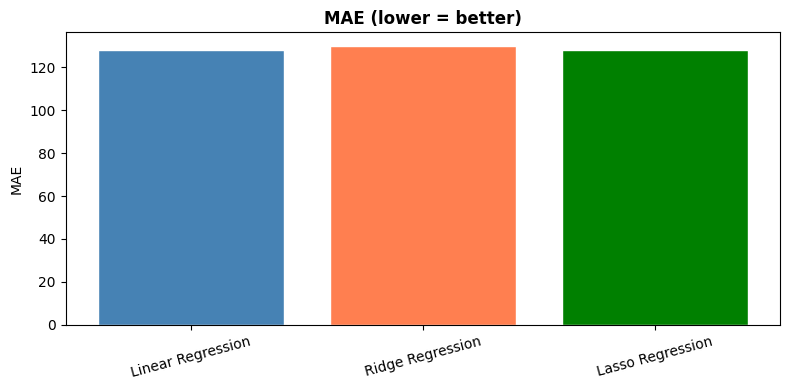

In [255]:
# ======== USE CONSOLIDATED PLOTTING FUNCTION ========
mae_series = pd.Series([results[m]['MAE'] for m in model_names], index=model_names)
plot_comparison(mae_series, 'MAE (lower = better)', 'MAE', kind='bar',
                color_list=['steelblue', 'coral', 'green'][:len(model_names)])
plt.show()

In [256]:
results_df = pd.DataFrame(results).T
best       = results_df['R2'].idxmax()
print("=" * 45)
print("FINAL MODEL COMPARISON")
print("=" * 45)
print(results_df)
print(f"\nBest Model : {best}")
print(f"R²         : {results_df.loc[best, 'R2']}")
print(f"MAE        : {results_df.loc[best, 'MAE']}")

FINAL MODEL COMPARISON
                      MAE    RMSE      R2
Linear Regression  128.02  181.50  0.9976
Ridge Regression   129.83  183.11  0.9975
Lasso Regression   128.13  181.55  0.9976

Best Model : Linear Regression
R²         : 0.9976
MAE        : 128.02


## Conclusion
- Feature engineering (delivery_rate, revenue_estimate, co2_per_delivery) added useful signal beyond raw columns
- Tesla deliveries show a strong upward trend from 2015–2025
- All three models performed similarly; the best was selected based on test R²
- ADF test confirmed the monthly series is non-stationary — differencing would be needed before ARIMA
- Chronological split was used for time series to prevent data leakage from future months